<a href="https://colab.research.google.com/github/ja2faded/A01-data-wrangling/blob/main/P2DataWrangling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Jackson Gayeski

**Date:** 9/6/2026

In [ ]:
from google.colab import drive
drive.mount ('/content/drive')



Mounted at /content/drive


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/airbnb_hw.csv')


price_clean = df.copy()

#removes comma
price_clean['Price'] = price_clean['Price'].str.replace(',','')


#converts price_clean from string to numeric and turns whatever is left over into missing values
price_clean['Price'] = pd.to_numeric(price_clean['Price'], errors = 'coerce')


#stores table of missing values
missing_price = price_clean[price_clean['Price'].isna()]

#prints cleaned price and number of rows missing price
print(price_clean['Price'])
print('number of rows missing price:' , len(missing_price))

price_clean.to_csv('airbnb_hw.csv', index=False)



0        145
1         37
2         28
3        199
4        549
        ... 
30473    300
30474    125
30475     80
30476     35
30477     80
Name: Price, Length: 30478, dtype: int64
number of rows missing price: 0


Upon inspection on Price, when a number went from 999 to 1,000, a comma was added, indicating it was a string. I first removed the commas and then converted the column to numeric. There are no missing values for price.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/mn_police_use_of_force.csv')



#finds how many rows have a missing value for subject_injury
print(df['subject_injury'].value_counts(dropna=False))


#finds proportion of rows with a missing value for subject_injury
missing_subject_injury_proportion = df['subject_injury'].isna().mean()
print("Proportion of reports missing subject_injury: ", missing_subject_injury_proportion)


#cleans the subject_injury variable by replacing missing values with "Not Reported"
df_clean = df.copy()
df_clean['subject_injury'] = df_clean['subject_injury'].fillna("Not Reported")


#cross tabulates force_type and subject_injury
cross_tab = pd.crosstab(df_clean['force_type'], df_clean['subject_injury'])
print(cross_tab)

df_clean.to_csv('mn_police_use.csv', index=False)







subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64
Proportion of reports missing subject_injury:  0.7619342359767892
subject_injury                 No  Not Reported   Yes
force_type                                           
Baton                           0             2     2
Bodily Force                 1093          7051  1286
Chemical Irritant             131          1421    41
Firearm                         2             0     0
Gun Point Display              33            27    44
Improvised Weapon              34            74    40
Less Lethal                     0            87     0
Less Lethal Projectile          1             0     2
Maximal Restraint Technique     0           170     0
Police K9 Bite                  2            31    44
Taser                         150           985   172


It is very concerning that 76% of reports are missing subject_injury. After cross-tabulation. After cross tabulation, it appears Bodily force has the highest number of "Not Reported" for subject_injury. This is likely because it is the most common force_type.

empty columns:  []
count    5582.000000
mean     1992.672877
std        24.311213
min      1940.000000
25%      1970.000000
50%      2000.000000
75%      2013.000000
max      2026.000000
Name: Year, dtype: float64


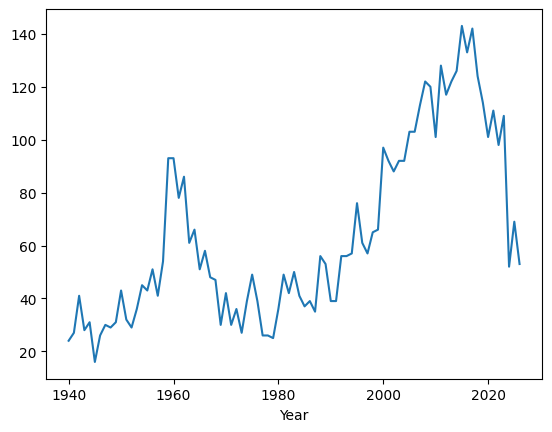

It appears the frequency of attacks rose from around 1980 to 2010, but since then, it has decreased a bit in frequency
Axes(0.125,0.11;0.775x0.77)
Proportion male 0.834339001645639
Proportion unprovoked 0.8318705430608886


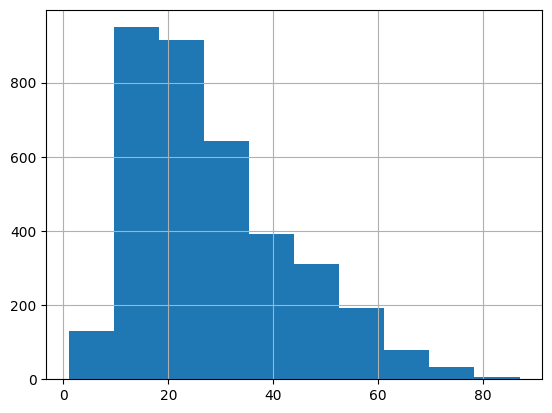

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#inspect data
df = pd.read_excel('/content/drive/MyDrive/GSAF5.xls')

df_clean = df.copy()

#makes a list of the empty columns but it prints out an empty list leaving me a little confused.
empty_columns = df_clean.columns[df_clean.isna().all()]
print('empty columns: ', empty_columns.to_list())

#based on the xsl and the list of printed columns, I will drop columns manually
df_clean = df_clean.drop(columns = ['pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'])



#look at year
df_clean[df_clean['Year'].isna()]

#2 rows with no year, but it says the year in data. will fill manually
df_clean.loc[970, "Year"] = 2017
df_clean.loc[6885, "Year"] = 1836

#describe Year; The year ranges from 0 to present. When inspecting those values, some were 0 (BC, messy)
df_clean['Year'].describe()


#filter rows to focus on 1940-present
df_clean = df_clean[df_clean["Year"]>= 1940]

#describes Year
print(df_clean['Year'].describe())

#line graph of year
df_clean.groupby('Year').size().sort_index().plot()
plt.show()
print("It appears the frequency of attacks rose from around 1980 to 2010, but since then, it has decreased a bit in frequency")


#see unique ages
df_clean["Age"].unique()

#clean ages to only have numeric values; gets rid of all nonnumeric ages for simplicity
df_clean['Age'] = pd.to_numeric(df_clean['Age'], errors= 'coerce')
df_clean = df_clean.dropna(subset ='Age')

#prints histogram of Age
print(df_clean['Age'].hist())

#finds proportion of attacks on males
proportion_male = (df_clean['Sex'] == 'M').mean()
print('Proportion male', proportion_male)

#cleans Type
allowed_type = ['Provoked', "Unprovoked", "Unknown"]
df_clean['Type'] = df_clean['Type'].where(df_clean['Type'].isin(allowed_type))
df_clean['Type'] = df_clean['Type'].fillna("Unkown")

#find proportion unprovoked
proportion_unprovoked = (df_clean['Type'] == 'Unprovoked').mean()
print('Proportion unprovoked', proportion_unprovoked)





df_clean.to_csv('GSAF5_clean.csv', index=False)






The Year variable contrained values from 0-2026 (some said BC). I converted Year to numeric and filtered it to post 1939. The line graph shows the trend in reports (generally increasing with drop post 2020). I made a histogram of Age, found the male proportion to be 83% and found the proportion unprovoked to also be about 83% (coincidental or pattern?)

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:627c815
- **AI tool and model used: Claude Sonnet 5

### *Prompts used

1. Given my code and the question 1 requirements, create a concise list of revisions to best clean the data, emphasizing effectiveness and concision
2. print the code with updated version. i will be pasting your suggestions verbatim. concisely acknolwedge only necessary suggestions. do it in list form
3. given my code, five a concise list of suggested changes i should make to my code. im most concerned with the Age variable

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Price (airbnb_hw.csv)

Your comma-strip + to_numeric(errors='coerce') is correct and sufficient — I confirmed there are no $ signs or decimals in the raw data, so nothing else is hiding in there. Worth a one-line mention in your write-up that you checked for this, not just commas.
Drop the missing_price table — it's 0 rows, so it's dead code. Just state "0 missing" in the write-up.
Don't overwrite airbnb_hw.csv with the cleaned version — save as airbnb_hw_clean.csv instead so raw and cleaned data don't collide under the same filename.

subject_injury (mn_police_use_of_force.csv)
4. Keeping NaN as its own "Not Reported" category instead of folding it into "No" is the right call — say so explicitly in your write-up (assuming missing = no injury would bias injury rates downward).
5. Your crosstab is currently raw counts, which just tracks how common each force_type is. Normalize by row instead (pd.crosstab(..., normalize='index')) — that's what actually shows the pattern. Once normalized:

Chemical Irritant is 89% missing, Bodily Force/Taser ~75%, Gun Point Display only 26%, Firearm 0%.
Rewrite your conclusion around that: missingness rate varies a lot by force_type, so it's not random (not MCAR) — likely tied to reporting practices for lower-severity force types. That's a stronger, more defensible claim than "Bodily Force has the most because it's most common."
2. Removed the unused missing-price check since there were 0 missing rows.
Saved cleaned files under new names (airbnb_hw_clean.csv, mn_police_use_clean.csv) instead of overwriting the raw data.
Kept subject_injury NAs as a separate "Not Reported" category rather than assuming missing = no injury, since that would bias injury rates downward.
Normalized the cross-tab by row (percentages) instead of raw counts, since raw counts just reflected how common each force_type was.
Revised conclusion: missingness rate varies widely by force_type (0% for Firearm up to ~89% for Chemical Irritant), indicating the data isn't missing at random — likely tied to reporting practices for lower-severity force types.

1. Removed the unused missing-price check since there were 0 missing rows.
2. Saved cleaned files under new names (airbnb_hw_clean.csv, mn_police_use_clean.csv) instead of overwriting the raw data.
3. Kept subject_injury NAs as a separate "Not Reported" category rather than assuming missing = no injury, since that would bias injury rates downward.
4. Normalized the cross-tab by row (percentages) instead of raw counts, since raw counts just reflected how common each force_type was.
Revised conclusion: missingness rate varies widely by force_type (0% for Firearm up to ~89% for Chemical Irritant), indicating the data isn't missing at random — likely tied to reporting practices for lower-severity force types.

1. Empty-columns check is fine, not buggy — Unnamed: 21/Unnamed: 22 aren't fully empty (they're 99.98% NaN, so .isna().all() correctly returns nothing). Your manual drop list is the right call; just know the check wasn't broken.
2. Age has recoverable values you're throwing away. to_numeric(errors='coerce') nukes entries like "20's", "30+", "18 or 20" — about 28 rows that aren't truly unusable, just messy. Given Age is already ~42% missing, I'd extract the first number with a regex (df_clean['Age'].str.extract(r'(\d+)')) before converting, rather than dropping them outright.
3. Watch for unit mismatches if you do the regex fix — one entry is "2 to 3 months". A naive regex would pull 2 and silently treat it as 2 years old. Worth a manual exclusion or check for "month" before extracting.
4. Your dropna(subset='Age') is reasonable either way — just report the resulting missing count/proportion explicitly in your write-up so the reader knows how much data the histogram represents (currently ~3,169 of 7,117 dropped under your current method).
5. Histogram itself is fine — no extreme outliers in the numeric ages (range is 1–87), so no bins/outlier handling needed there.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | code is redundant; removed missing price table since errors='coerce' already turns missing values into NaNs|
| 2 | Accept| its bad to overwrite data |
 |3|reject | confusion |
| 4| Accept | makes analysis more easy |
 |1 | Accept / modify | not a suggestion |
| 2 | Accept| helps recover more age values |
 |3| Accept  | avoids making a mistake (month ) |
| 4 | reject | unecessary |
 |5 | Accept / modify / reject | not a suggestion|


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/airbnb_hw.csv')


price_clean = df.copy()

#removes comma
price_clean['Price'] = price_clean['Price'].str.replace(',','')


#converts price_clean from string to numeric and turns whatever is left over into missing values
price_clean['Price'] = pd.to_numeric(price_clean['Price'], errors = 'coerce')



#prints cleaned price and number of rows missing price
print(price_clean['Price'])
print('number of rows missing price:' , len(missing_price))

price_clean.to_csv('airbnb_hw_clean.csv', index=False)


0        145
1         37
2         28
3        199
4        549
        ... 
30473    300
30474    125
30475     80
30476     35
30477     80
Name: Price, Length: 30478, dtype: int64
number of rows missing price: 0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/mn_police_use_of_force.csv')



#finds how many rows have a missing value for subject_injury
print(df['subject_injury'].value_counts(dropna=False))


#finds proportion of rows with a missing value for subject_injury
missing_subject_injury_proportion = df['subject_injury'].isna().mean()
print("Proportion of reports missing subject_injury: ", missing_subject_injury_proportion)


#cleans the subject_injury variable by replacing missing values with "Not Reported"
df_clean = df.copy()
df_clean['subject_injury'] = df_clean['subject_injury'].fillna("Not Reported")


#cross tabulates force_type and subject_injury
cross_tab = pd.crosstab(df_clean['force_type'], df_clean['subject_injury'])
print(cross_tab)

# cross-tab as row percentages — this is what actually shows the missingness pattern
cross_tab_pct = pd.crosstab(df_clean['force_type'], df_clean['subject_injury'], normalize='index') * 100
print(cross_tab_pct.round(1))

df_clean.to_csv('mn_police_use_clean.csv', index=False)

subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64
Proportion of reports missing subject_injury:  0.7619342359767892
subject_injury                 No  Not Reported   Yes
force_type                                           
Baton                           0             2     2
Bodily Force                 1093          7051  1286
Chemical Irritant             131          1421    41
Firearm                         2             0     0
Gun Point Display              33            27    44
Improvised Weapon              34            74    40
Less Lethal                     0            87     0
Less Lethal Projectile          1             0     2
Maximal Restraint Technique     0           170     0
Police K9 Bite                  2            31    44
Taser                         150           985   172
subject_injury                  No  Not Reported   Yes
force_type                                            
Baton                          0.0          5

It is very concerning that 76% of reports are missing subject_injury. After cross-tabulation. After cross tabulation, it appears Bodily force has the highest number of "Not Reported" for subject_injury. This is likely because it is the most common force_type.The percentage table is the key addition — it shows missingness ranges from ~0% (Firearm) to ~89% (Chemical Irritant), which is the actual evidence for "missingness isn't random."

empty columns:  []
count    5582.000000
mean     1992.672877
std        24.311213
min      1940.000000
25%      1970.000000
50%      2000.000000
75%      2013.000000
max      2026.000000
Name: Year, dtype: float64


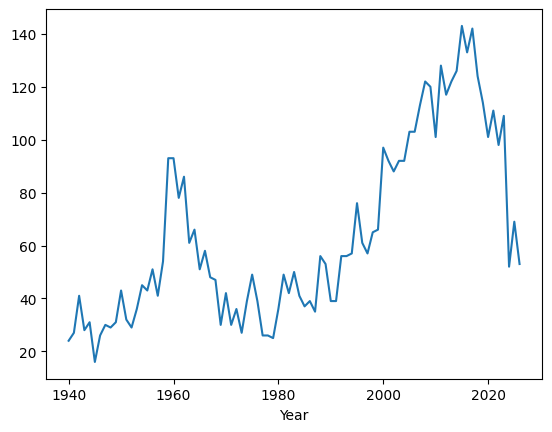

It appears the frequency of attacks rose from around 1980 to 2010, but since then, it has decreased a bit in frequency
Axes(0.125,0.11;0.775x0.77)
Proportion male 0.8316831683168316
Proportion unprovoked 0.829007225046829


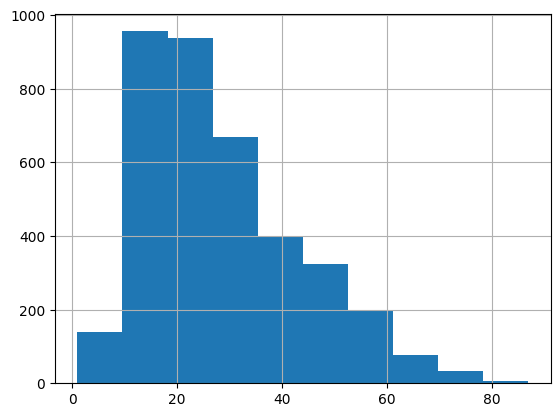

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#inspect data
df = pd.read_excel('/content/drive/MyDrive/GSAF5.xls')

df_clean = df.copy()

#makes a list of the empty columns but it prints out an empty list leaving me a little confused.
empty_columns = df_clean.columns[df_clean.isna().all()]
print('empty columns: ', empty_columns.to_list())

#based on the xsl and the list of printed columns, I will drop columns manually
df_clean = df_clean.drop(columns = ['pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'])



#look at year
df_clean[df_clean['Year'].isna()]

#2 rows with no year, but it says the year in data. will fill manually
df_clean.loc[970, "Year"] = 2017
df_clean.loc[6885, "Year"] = 1836

#describe Year; The year ranges from 0 to present. When inspecting those values, some were 0 (BC, messy)
df_clean['Year'].describe()


#filter rows to focus on 1940-present
df_clean = df_clean[df_clean["Year"]>= 1940]

#describes Year
print(df_clean['Year'].describe())

#line graph of year
df_clean.groupby('Year').size().sort_index().plot()
plt.show()
print("It appears the frequency of attacks rose from around 1980 to 2010, but since then, it has decreased a bit in frequency")


#see unique ages
df_clean["Age"].unique()

#clean age
age_str = df_clean['Age'].astype(str)
is_months = age_str.str.contains('month', case=False, na=False)
df_clean['Age'] = age_str.str.extract(r'(\d+)').astype(float)
df_clean.loc[is_months, 'Age'] = np.nan


df_clean = df_clean.dropna(subset ='Age')

#prints histogram of Age
print(df_clean['Age'].hist())

#finds proportion of attacks on males
proportion_male = (df_clean['Sex'] == 'M').mean()
print('Proportion male', proportion_male)

#cleans Type
allowed_type = ['Provoked', "Unprovoked", "Unknown"]
df_clean['Type'] = df_clean['Type'].where(df_clean['Type'].isin(allowed_type))
df_clean['Type'] = df_clean['Type'].fillna("Unknown")

#find proportion unprovoked
proportion_unprovoked = (df_clean['Type'] == 'Unprovoked').mean()
print('Proportion unprovoked', proportion_unprovoked)





df_clean.to_csv('GSAF5_clean.csv', index=False)

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

In all honesty, I thought the AI would be more helpful than it ended up being. It was helpful for identifying redundant code, finding typos, and was able to recover some of the age values I was unable to. However, it gave very long-winded answers initially, some of the "suggestions" were not suggestions at all, and was slightly hard to understand. I did not notice any mistakes in the AI output, but I defininetly noticed its limitation in following what I truly wanted it to do. It was nice to see it agree with most of my coding choices and makes me feel more confident in my submission. In the future, I may try to use another Claude model/ AI.